<a href="https://colab.research.google.com/github/fitridianamusa/Artikel-ADW-Kelompok-8/blob/main/GARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

## Data

In [104]:
import pandas as pd

url = "https://raw.githubusercontent.com/fitridianamusa/Artikel-ADW-Kelompok-8/main/Data%20Historis%20USD_IDR.csv"

data = pd.read_csv(url)

print(data.head())
print(data.columns)
print(data.shape)

# Memilih Kolom
data = data[["Tanggal", "Terakhir"]].copy()


# Konversi tanggal
data["Tanggal"] = pd.to_datetime(
    data["Tanggal"],
    dayfirst=True
)


# Konversi Nilai Terakhir Menjadi Numerik
data["Terakhir"] = (
    data["Terakhir"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)


# Urutan Berdasarkan Tanggal
data = data.sort_values(
    by="Tanggal"
).reset_index(drop=True)


# Cek hasil
print(data.head())
print(data.tail())
print(data.info())

      Tanggal  Terakhir Pembukaan Tertinggi  Terendah Vol. Perubahan%
0  01/09/2026  17.715,0  17.725,0  17.735,0  17.704,5  NaN      0,00%
1  31/08/2026  17.715,0  17.750,0  17.770,0  17.712,5  NaN      0,14%
2  28/08/2026  17.690,0  17.715,0  17.722,5  17.679,0  NaN     -0,17%
3  27/08/2026  17.720,0  17.760,0  17.790,0  17.720,0  NaN      0,11%
4  26/08/2026  17.700,0  17.695,0  17.733,5  17.677,5  NaN     -0,06%
Index(['Tanggal', 'Terakhir', 'Pembukaan', 'Tertinggi', 'Terendah', 'Vol.',
       'Perubahan%'],
      dtype='object')
(1442, 7)
     Tanggal  Terakhir
0 2021-01-01   14213.7
1 2021-01-04   13885.0
2 2021-01-05   13900.0
3 2021-01-06   13880.0
4 2021-01-07   13890.0
        Tanggal  Terakhir
1437 2026-08-26   17700.0
1438 2026-08-27   17720.0
1439 2026-08-28   17690.0
1440 2026-08-31   17715.0
1441 2026-09-01   17715.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
--- 

In [108]:
print("\nInformasi data:")
print(data.info())

print("\nJumlah observasi:")
print(len(data))

print("\nStatistik deskriptif:")
print(data["Terakhir"].describe())

print("\nMissing value:")
print(data.isnull().sum())


Informasi data:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2021-01-01 to 2026-09-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Terakhir  1442 non-null   float64
dtypes: float64(1)
memory usage: 22.5 KB
None

Jumlah observasi:
1442

Statistik deskriptif:
count     1442.000000
mean     15601.574549
std       1024.339256
min      13880.000000
25%      14705.000000
50%      15572.500000
75%      16330.000000
max      18175.000000
Name: Terakhir, dtype: float64

Missing value:
Terakhir    0
dtype: int64


In [110]:
print("KOLOM:")
print(data.columns)

print("\nNAMA INDEX:")
print(data.index.name)

print("\n5 DATA TERATAS:")
display(data.head())

KOLOM:
Index(['Terakhir'], dtype='object')

NAMA INDEX:
Tanggal

5 DATA TERATAS:


,Terakhir
Tanggal,
2021-01-01,14213.7
2021-01-04,13885.0
2021-01-05,13900.0
2021-01-06,13880.0
2021-01-07,13890.0


## Preprocessing Data

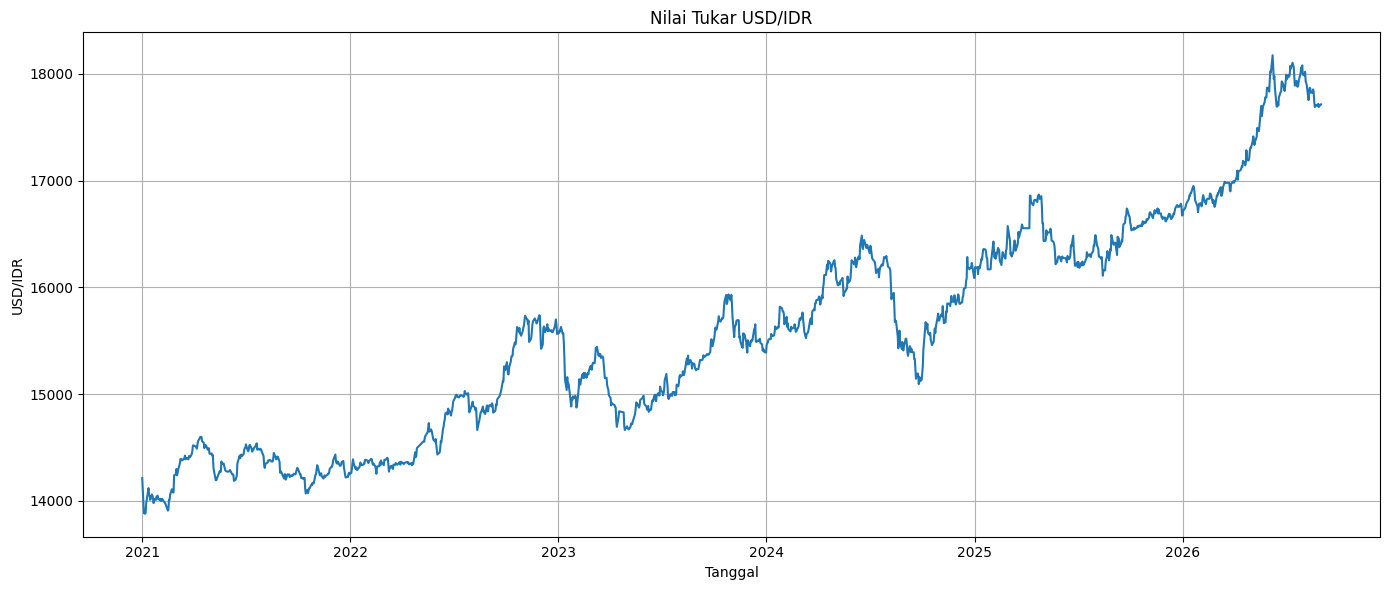

In [111]:
# Plot Data Awal
plt.figure(figsize=(14, 6))

plt.plot(
    data.index,
    data["Terakhir"]
)

plt.title("Nilai Tukar USD/IDR")
plt.xlabel("Tanggal")
plt.ylabel("USD/IDR")

plt.grid(True)
plt.tight_layout()
plt.show()

#Training dan Testing

In [112]:
n_train = 1400

train = data.iloc[:n_train].copy()
test = data.iloc[n_train:].copy()

print("\n======================================")
print("PEMBAGIAN DATA")
print("======================================")

print("Total observasi  :", len(data))
print("Training         :", len(train))
print("Testing          :", len(test))

print("\nPeriode Training:")
print(train.index.min(), "sampai", train.index.max())

print("\nPeriode Testing:")
print(test.index.min(), "sampai", test.index.max())


PEMBAGIAN DATA
Total observasi  : 1442
Training         : 1400
Testing          : 42

Periode Training:
2021-01-01 00:00:00 sampai 2026-07-03 00:00:00

Periode Testing:
2026-07-06 00:00:00 sampai 2026-09-01 00:00:00


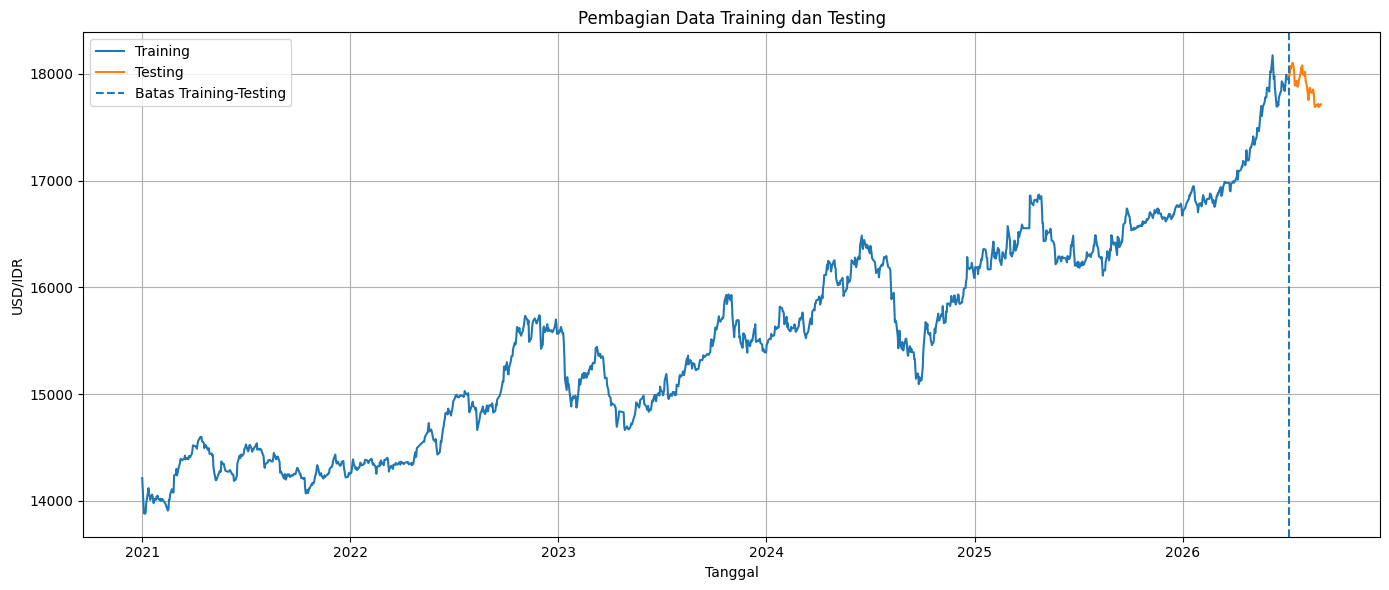

In [113]:
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train["Terakhir"],
    label="Training"
)

plt.plot(
    test.index,
    test["Terakhir"],
    label="Testing"
)

plt.axvline(
    x=test.index[0],
    linestyle="--",
    label="Batas Training-Testing"
)

plt.title("Pembagian Data Training dan Testing")
plt.xlabel("Tanggal")
plt.ylabel("USD/IDR")
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

In [114]:
y_train = train["Terakhir"]
y_test = test["Terakhir"]

## Uji Stasioneritas

In [115]:
def uji_adf(data_series, nama_data):

    hasil = adfuller(data_series.dropna())

    adf_stat = hasil[0]
    p_value = hasil[1]

    print("\n======================================")
    print(f"UJI ADF - {nama_data}")
    print("======================================")
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"p-value       : {p_value:.4f}")

    print("\nCritical Value:")

    for key, value in hasil[4].items():
        print(f"{key} : {value:.4f}")

    print("\nKeputusan:")

    if p_value < 0.05:
        print("Tolak H0")
        print("Kesimpulan: Data stasioner dalam rataan.")
    else:
        print("Gagal menolak H0")
        print("Kesimpulan: Data tidak stasioner dalam rataan.")


uji_adf(y_train, "Data Training")


UJI ADF - Data Training
ADF Statistic : -0.0584
p-value       : 0.9534

Critical Value:
1% : -3.4351
5% : -2.8636
10% : -2.5679

Keputusan:
Gagal menolak H0
Kesimpulan: Data tidak stasioner dalam rataan.


/tmp/ipykernel_1638/1325515459.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  hasil = adfuller(data_series.dropna())


## Differencing

In [116]:
y_train_diff = y_train.diff().dropna()

print("Data sebelum differencing :", len(y_train))
print("Data setelah differencing  :", len(y_train_diff))

print("\n5 data pertama setelah differencing:")
print(y_train_diff.head())

Data sebelum differencing : 1400
Data setelah differencing  : 1399

5 data pertama setelah differencing:
Tanggal
2021-01-04   -328.7
2021-01-05     15.0
2021-01-06    -20.0
2021-01-07     10.0
2021-01-08     90.0
Name: Terakhir, dtype: float64


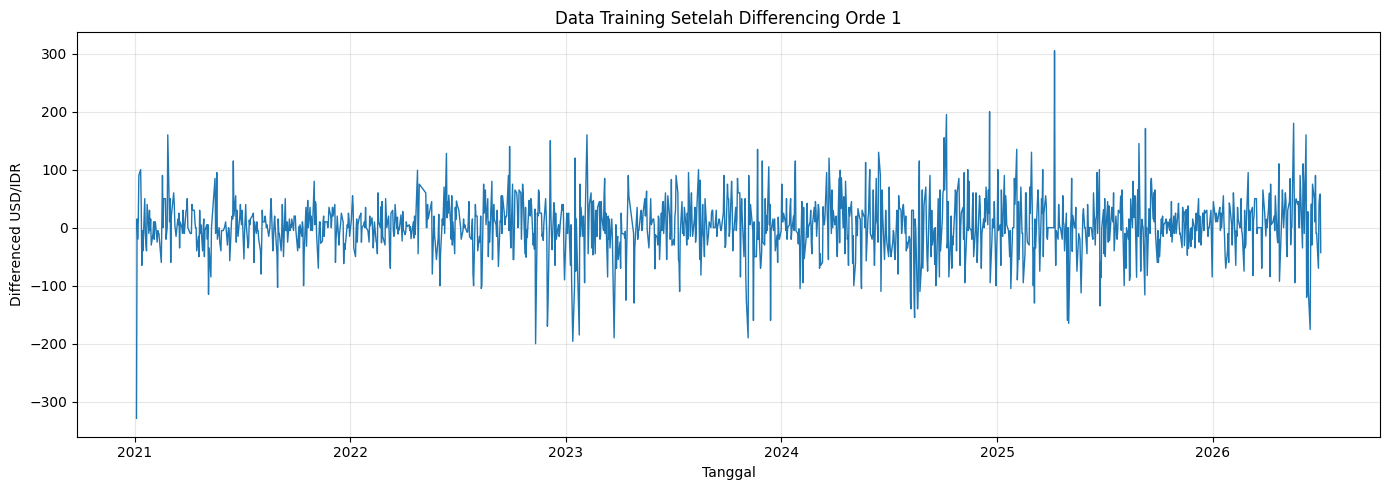

In [117]:
plt.figure(figsize=(14, 5))

plt.plot(
    y_train_diff.index,
    y_train_diff,
    linewidth=1
)

plt.title("Data Training Setelah Differencing Orde 1")
plt.xlabel("Tanggal")
plt.ylabel("Differenced USD/IDR")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Uji stasioneritas

In [118]:
#ADF
stasioner_diff = uji_adf(
    y_train_diff,
    "Data Setelah Differencing"
)


UJI ADF - Data Setelah Differencing
ADF Statistic : -13.4654
p-value       : 0.0000

Critical Value:
1% : -3.4351
5% : -2.8636
10% : -2.5679

Keputusan:
Tolak H0
Kesimpulan: Data stasioner dalam rataan.


/tmp/ipykernel_1638/1325515459.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  hasil = adfuller(data_series.dropna())


HASIL BOX-COX
Lambda optimal : 1.3852
95% CI         : (1.2196, 1.5582)
Shift          : 329.7000


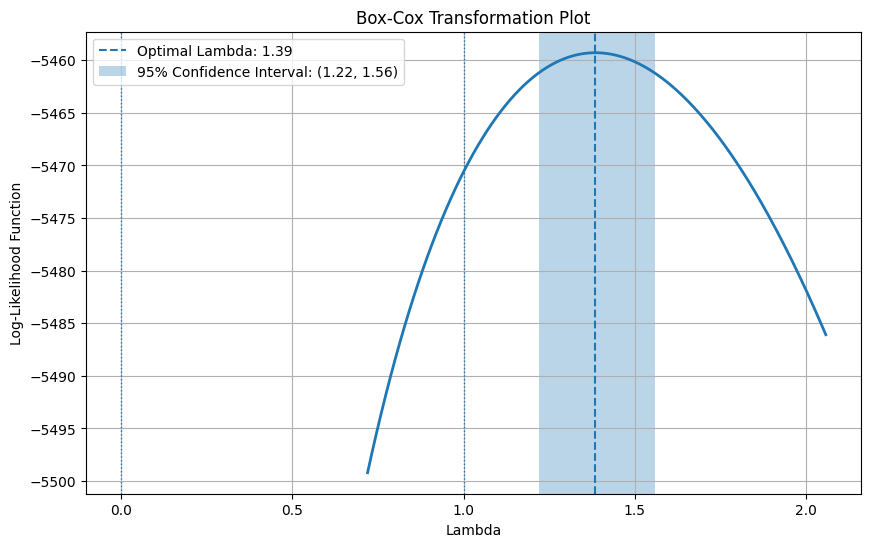

In [119]:
#Stasioneritas dalam Ragam
from scipy.stats import boxcox, boxcox_llf
import numpy as np
import matplotlib.pyplot as plt

# Data setelah differencing
data_diff = y_train_diff.dropna()

# SHIFT DATA JIKA ADA NILAI <= 0
if data_diff.min() <= 0:
    shift = abs(data_diff.min()) + 1
    data_boxcox = data_diff + shift
else:
    shift = 0
    data_boxcox = data_diff.copy()


# MENENTUKAN LAMBDA OPTIMAL DAN 95% CI
_, lambda_fit, ci = boxcox(
    data_boxcox,
    alpha=0.05
)

print("======================================")
print("HASIL BOX-COX")
print("======================================")
print(f"Lambda optimal : {lambda_fit:.4f}")
print(f"95% CI         : ({ci[0]:.4f}, {ci[1]:.4f})")
print(f"Shift          : {shift:.4f}")


# RENTANG LAMBDA UNTUK PLOT
lambdas = np.linspace(
    ci[0] - 0.5,
    ci[1] + 0.5,
    300
)

# Hitung log-likelihood untuk setiap lambda
llf = [
    boxcox_llf(lmbda, data_boxcox)
    for lmbda in lambdas
]


# PLOT BOX-COX
plt.figure(figsize=(10, 6))

plt.plot(
    lambdas,
    llf,
    linewidth=2
)

# Lambda optimal
plt.axvline(
    lambda_fit,
    linestyle='--',
    linewidth=1.5,
    label=f'Optimal Lambda: {lambda_fit:.2f}'
)

# Confidence interval 95%
plt.axvspan(
    ci[0],
    ci[1],
    alpha=0.3,
    label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})'
)

# Lambda = 0 dan 1 sebagai referensi
plt.axvline(
    0,
    linestyle=':',
    linewidth=1
)

plt.axvline(
    1,
    linestyle=':',
    linewidth=1
)

plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend()
plt.grid(True)

plt.show()

## Transformasi

In [120]:
# TRANSFORMASI BOX-COX
from scipy.stats import boxcox

# Transformasi menggunakan lambda optimal
y_train_boxcox = boxcox(
    data_boxcox,
    lmbda=lambda_fit
)

# Jadikan Series agar index tetap sama
y_train_boxcox = pd.Series(
    y_train_boxcox,
    index=y_train_diff.index
)

print("======================================")
print("TRANSFORMASI BOX-COX")
print("======================================")
print(f"Lambda yang digunakan : {lambda_fit:.4f}")
print(f"Shift yang digunakan  : {shift:.4f}")

print("\n5 data pertama setelah transformasi:")
print(y_train_boxcox.head())

TRANSFORMASI BOX-COX
Lambda yang digunakan : 1.3852
Shift yang digunakan  : 329.7000

5 data pertama setelah transformasi:
Tanggal
2021-01-04       0.000000
2021-01-05    2361.131230
2021-01-06    2035.584066
2021-01-07    2313.809377
2021-01-08    3101.554617
dtype: float64


In [121]:
print(data.columns)

Index(['Terakhir'], dtype='object')


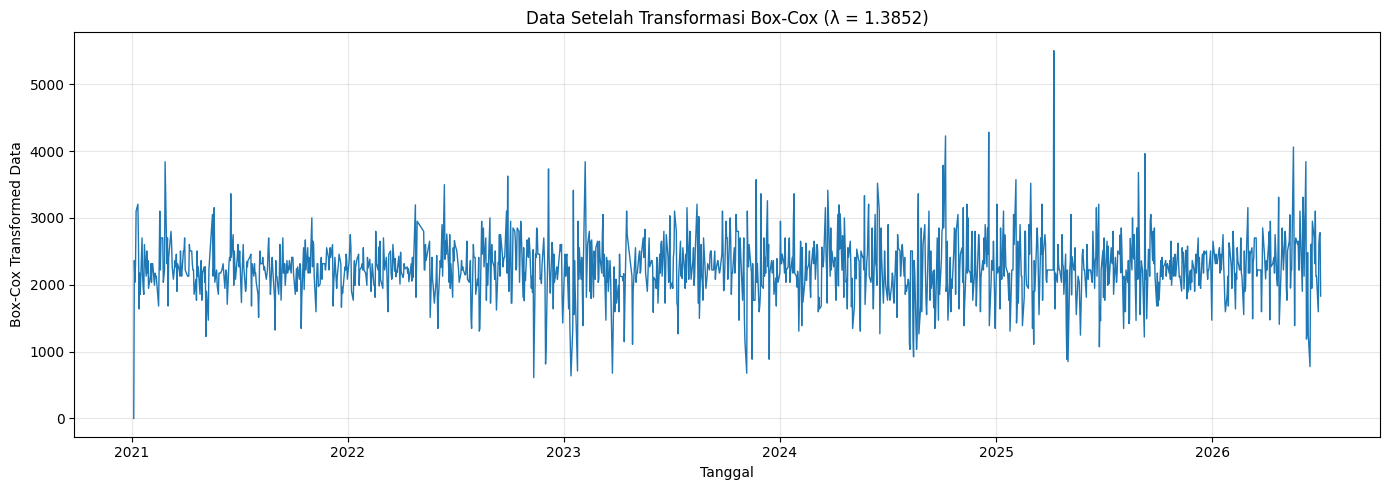

In [122]:
# ============================================
# PLOT SETELAH TRANSFORMASI BOX-COX
# ============================================

plt.figure(figsize=(14, 5))

plt.plot(
    y_train_boxcox.index,
    y_train_boxcox,
    linewidth=1
)

plt.title(
    f"Data Setelah Transformasi Box-Cox (λ = {lambda_fit:.4f})"
)

plt.xlabel("Tanggal")
plt.ylabel("Box-Cox Transformed Data")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Stasioneritas

In [123]:
# Stasioneritas dalam Rataan
from statsmodels.tsa.stattools import adfuller

def uji_adf(data_series, nama_data):
    hasil = adfuller(data_series.dropna())

    adf_stat = hasil[0]
    p_value = hasil[1]

    print("\n======================================")
    print(f"UJI ADF - {nama_data}")
    print("======================================")
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"p-value       : {p_value:.4f}")

    print("\nCritical Value:")
    for key, value in hasil[4].items():
        print(f"{key} : {value:.4f}")

    if p_value < 0.05:
        print("\nKeputusan : Tolak H0")
        print("Kesimpulan: Data stasioner dalam rataan.")
        return True
    else:
        print("\nKeputusan : Gagal menolak H0")
        print("Kesimpulan: Data tidak stasioner dalam rataan.")
        return False


# ADF setelah transformasi Box-Cox
stasioner_boxcox = uji_adf(
    y_train_boxcox,
    "Data Setelah Transformasi Box-Cox"
)


UJI ADF - Data Setelah Transformasi Box-Cox
ADF Statistic : -13.5721
p-value       : 0.0000

Critical Value:
1% : -3.4351
5% : -2.8636
10% : -2.5679

Keputusan : Tolak H0
Kesimpulan: Data stasioner dalam rataan.


/tmp/ipykernel_1638/2564269602.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  hasil = adfuller(data_series.dropna())


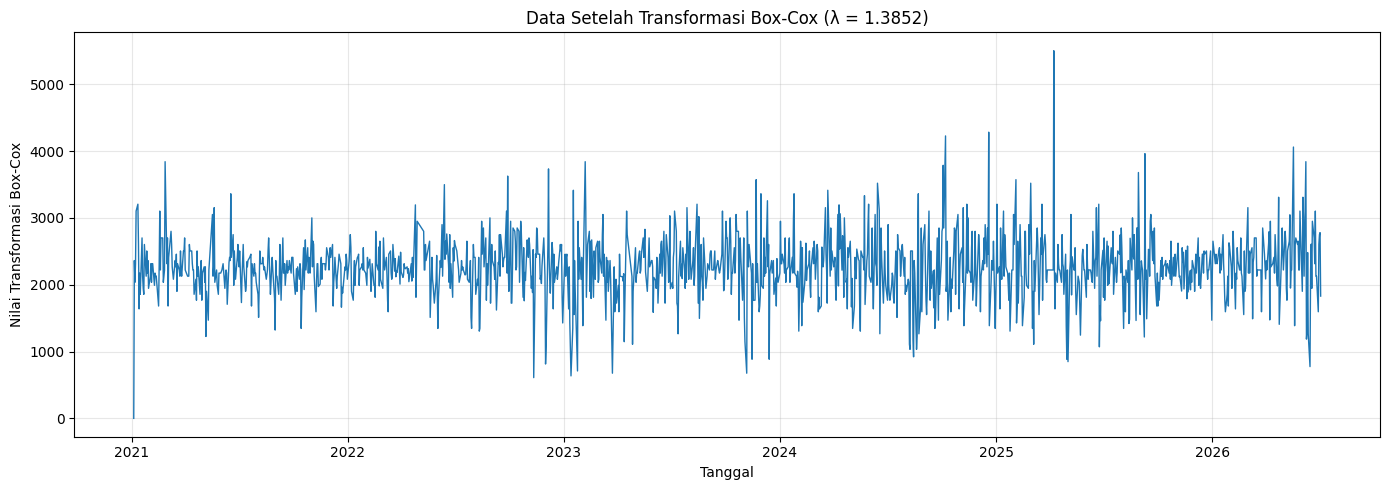

In [124]:
# Stasioneritas dalam Ragam
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    y_train_boxcox.index,
    y_train_boxcox,
    linewidth=1
)

plt.title(
    f"Data Setelah Transformasi Box-Cox (λ = {lambda_fit:.4f})"
)

plt.xlabel("Tanggal")
plt.ylabel("Nilai Transformasi Box-Cox")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [125]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(
    y_train_boxcox.dropna(),
    nlags=10
)

print("======================================")
print("UJI ARCH-LM")
print("======================================")
print(f"LM Statistic : {arch_test[0]:.4f}")
print(f"LM p-value   : {arch_test[1]:.4f}")
print(f"F Statistic  : {arch_test[2]:.4f}")
print(f"F p-value    : {arch_test[3]:.4f}")

if arch_test[1] < 0.05:
    print("\nKeputusan : Tolak H0")
    print("Kesimpulan: Terdapat efek ARCH / ragam belum konstan.")
else:
    print("\nKeputusan : Gagal menolak H0")
    print("Kesimpulan: Tidak terdapat bukti efek ARCH yang signifikan.")

UJI ARCH-LM
LM Statistic : 12.3342
LM p-value   : 0.2633
F Statistic  : 1.2346
F p-value    : 0.2638

Keputusan : Gagal menolak H0
Kesimpulan: Tidak terdapat bukti efek ARCH yang signifikan.


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


## ACF & PACF

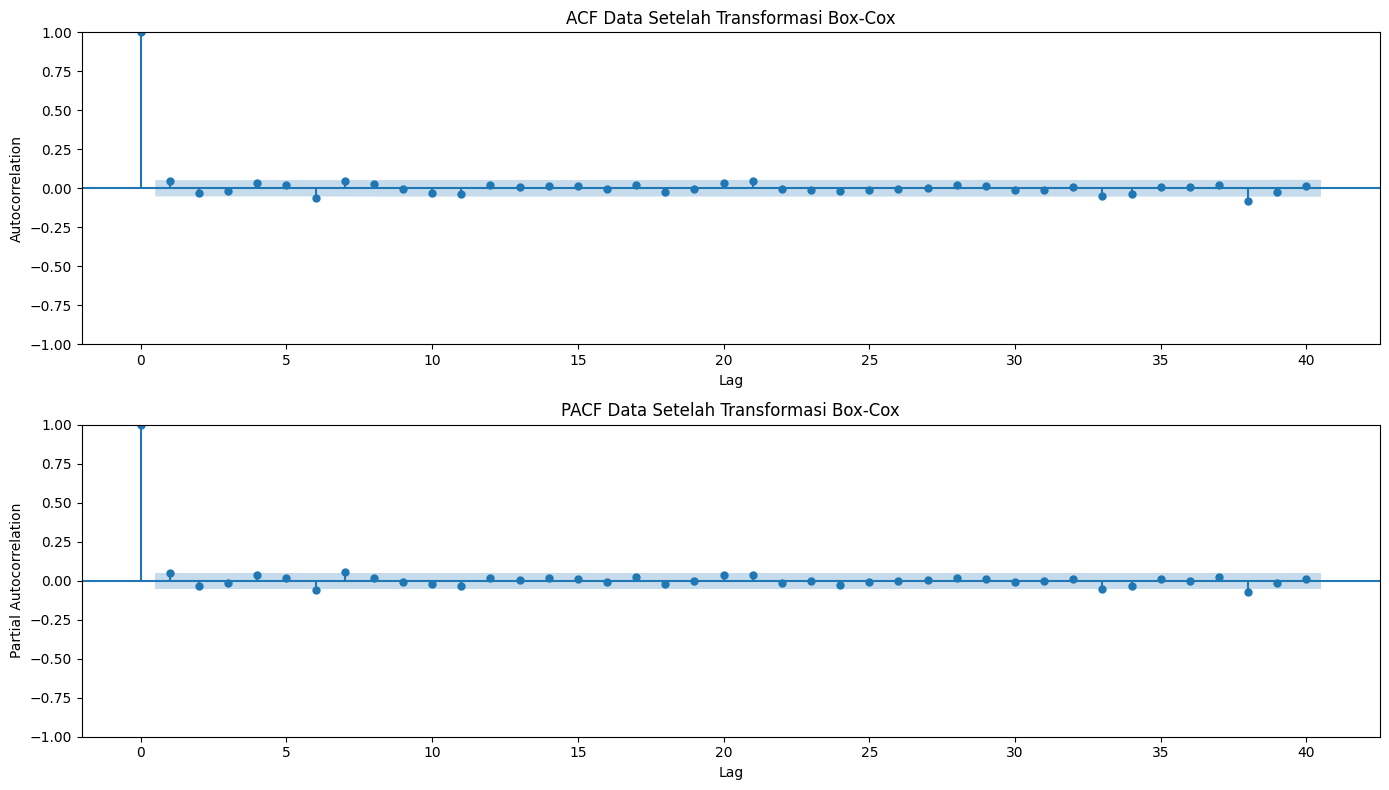

In [126]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(
    y_train_boxcox,
    lags=40,
    ax=axes[0]
)
axes[0].set_title("ACF Data Setelah Transformasi Box-Cox")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(
    y_train_boxcox,
    lags=40,
    ax=axes[1],
    method="ywm"
)
axes[1].set_title("PACF Data Setelah Transformasi Box-Cox")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

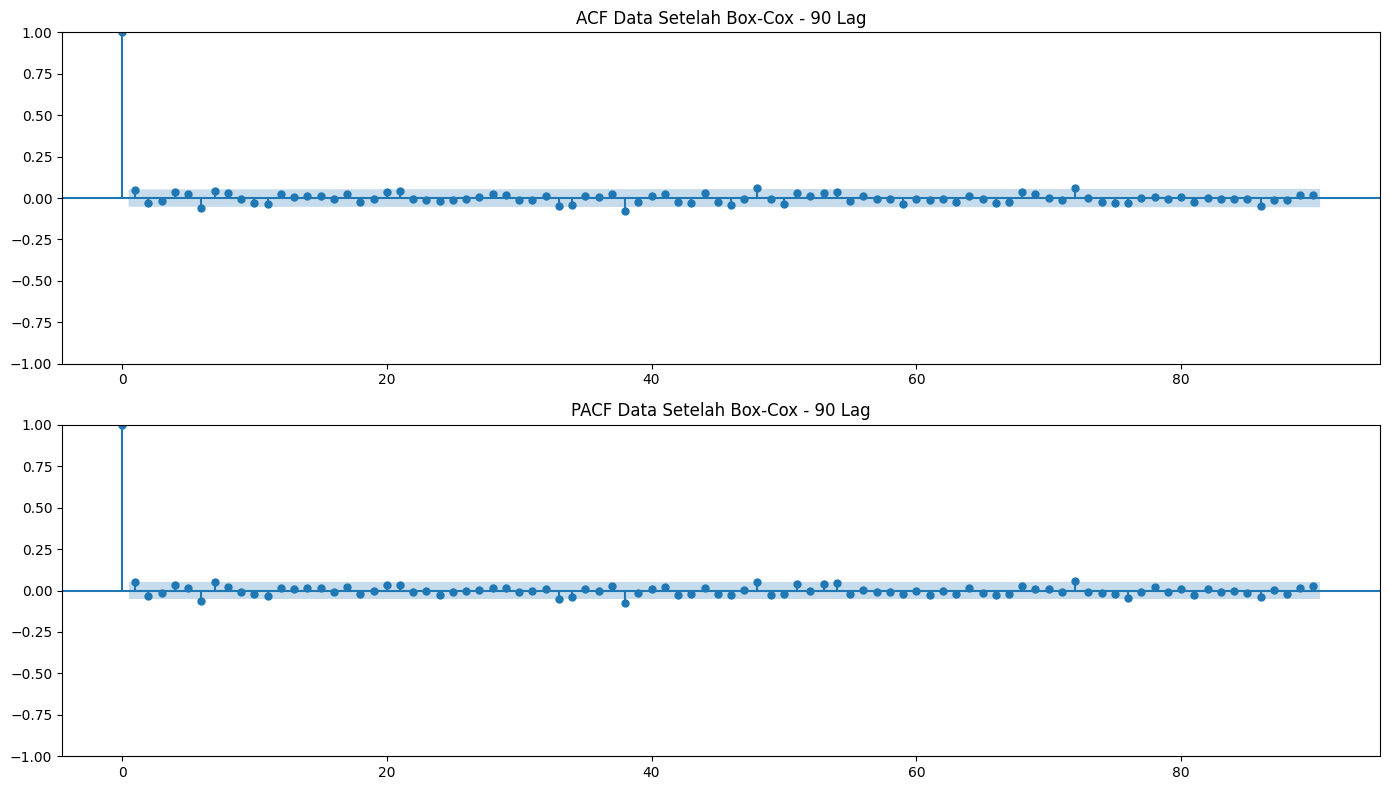

In [127]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(
    y_train_boxcox,
    lags=90,
    ax=axes[0]
)
axes[0].set_title("ACF Data Setelah Box-Cox - 90 Lag")

plot_pacf(
    y_train_boxcox,
    lags=90,
    ax=axes[1],
    method="ywm"
)
axes[1].set_title("PACF Data Setelah Box-Cox - 90 Lag")

plt.tight_layout()
plt.show()

## GARCH

In [128]:
!pip install arch -q

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arch import arch_model

In [130]:
y_garch = y_train_boxcox.dropna().copy()

In [131]:
print("Jumlah observasi:", len(y_garch))
print(y_garch.head())

Jumlah observasi: 1399
Tanggal
2021-01-04       0.000000
2021-01-05    2361.131230
2021-01-06    2035.584066
2021-01-07    2313.809377
2021-01-08    3101.554617
dtype: float64


In [132]:
model_garch = arch_model(
    y_garch,
    mean='ARX',
    lags=1,
    vol='GARCH',
    p=1,
    q=1,
    dist='normal'
)

hasil_garch = model_garch.fit(disp='off')

print(hasil_garch.summary())

                           AR - GARCH Model Results                           
Dep. Variable:                   None   R-squared:                       0.002
Mean Model:                        AR   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:               -10492.6
Distribution:                  Normal   AIC:                           20995.3
Method:            Maximum Likelihood   BIC:                           21021.5
                                        No. Observations:                 1398
Date:                Fri, Oct 02 2026   Df Residuals:                     1396
Time:                        07:29:09   Df Model:                            2
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const       2131.4845     66.064     32.264 2.256e-228 [2.

/usr/local/lib/python3.13/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.082e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [133]:
print("======================================")
print("PARAMETER MODEL AR(1)-GARCH(1,1)")
print("======================================")

print(hasil_garch.params)

print("\nP-VALUE:")
print(hasil_garch.pvalues)

PARAMETER MODEL AR(1)-GARCH(1,1)
Const       2131.484540
None[1]        0.056402
omega       4154.654101
alpha[1]       0.043645
beta[1]        0.937867
Name: params, dtype: float64

P-VALUE:
Const       2.256111e-228
None[1]      4.756054e-02
omega        8.681566e-01
alpha[1]     5.832571e-01
beta[1]      1.386650e-06
Name: pvalues, dtype: float64


In [134]:
alpha = hasil_garch.params["alpha[1]"]
beta = hasil_garch.params["beta[1]"]

print("======================================")
print("PERSISTENSI VOLATILITAS")
print("======================================")
print(f"Alpha (α1) : {alpha:.6f}")
print(f"Beta (β1)  : {beta:.6f}")
print(f"Alpha + Beta : {alpha + beta:.6f}")

PERSISTENSI VOLATILITAS
Alpha (α1) : 0.043645
Beta (β1)  : 0.937867
Alpha + Beta : 0.981512


In [135]:
std_resid = hasil_garch.std_resid.dropna()

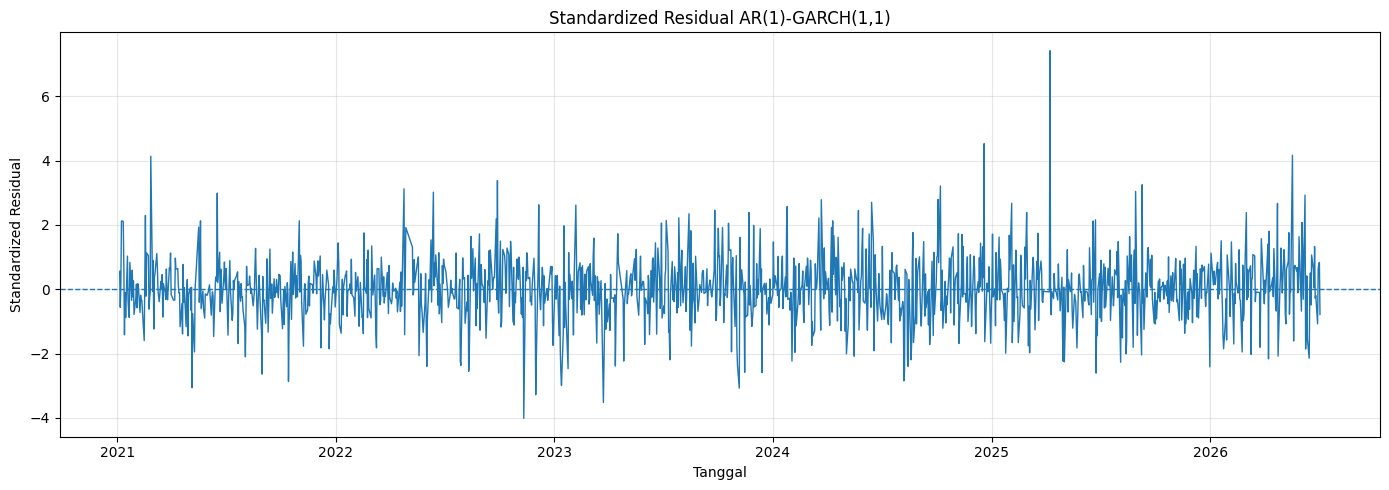

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    std_resid.index,
    std_resid,
    linewidth=1
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.title("Standardized Residual AR(1)-GARCH(1,1)")
plt.xlabel("Tanggal")
plt.ylabel("Standardized Residual")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## UJI Ljung-Box Residual

In [137]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_resid = acorr_ljungbox(
    std_resid,
    lags=[10, 20],
    return_df=True
)

print("======================================")
print("UJI LJUNG-BOX STANDARDIZED RESIDUAL")
print("======================================")
print(ljung_resid)

UJI LJUNG-BOX STANDARDIZED RESIDUAL
      lb_stat  lb_pvalue
10  15.413233   0.117707
20  21.046587   0.394395


In [138]:
ljung_squared = acorr_ljungbox(
    std_resid**2,
    lags=[10, 20],
    return_df=True
)

print("======================================")
print("UJI LJUNG-BOX KUADRAT STANDARDIZED RESIDUAL")
print("======================================")
print(ljung_squared)

UJI LJUNG-BOX KUADRAT STANDARDIZED RESIDUAL
     lb_stat  lb_pvalue
10  5.261357   0.873049
20  7.734173   0.993485


In [139]:
from statsmodels.stats.diagnostic import het_arch

arch_after = het_arch(
    std_resid,
    nlags=10
)

print("======================================")
print("UJI ARCH-LM SETELAH GARCH(1,1)")
print("======================================")
print(f"LM Statistic : {arch_after[0]:.4f}")
print(f"LM p-value   : {arch_after[1]:.4f}")
print(f"F Statistic  : {arch_after[2]:.4f}")
print(f"F p-value    : {arch_after[3]:.4f}")

UJI ARCH-LM SETELAH GARCH(1,1)
LM Statistic : 5.1997
LM p-value   : 0.8774
F Statistic  : 0.5178
F p-value    : 0.8786


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


In [140]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box residual
lb_resid = acorr_ljungbox(
    std_resid,
    lags=10,
    return_df=True
)

print("======================================")
print("UJI LJUNG-BOX RESIDUAL TERSTANDARISASI")
print("======================================")
print(lb_resid)

# Ljung-Box residual kuadrat
lb_resid_sq = acorr_ljungbox(
    std_resid**2,
    lags=10,
    return_df=True
)

print("\n======================================")
print("UJI LJUNG-BOX RESIDUAL TERSTANDARISASI KUADRAT")
print("======================================")
print(lb_resid_sq)

UJI LJUNG-BOX RESIDUAL TERSTANDARISASI
      lb_stat  lb_pvalue
1    0.186031   0.666240
2    0.813587   0.665782
3    1.271471   0.735918
4    4.188098   0.381148
5    6.391737   0.269945
6   11.866283   0.065019
7   13.291946   0.065307
8   15.148582   0.056320
9   15.150616   0.086881
10  15.413233   0.117707

UJI LJUNG-BOX RESIDUAL TERSTANDARISASI KUADRAT
     lb_stat  lb_pvalue
1   0.577949   0.447117
2   0.820148   0.663601
3   0.824991   0.843481
4   0.842524   0.932658
5   2.429404   0.787087
6   3.362825   0.762122
7   3.763074   0.806626
8   4.865671   0.771832
9   5.252855   0.811733
10  5.261357   0.873049


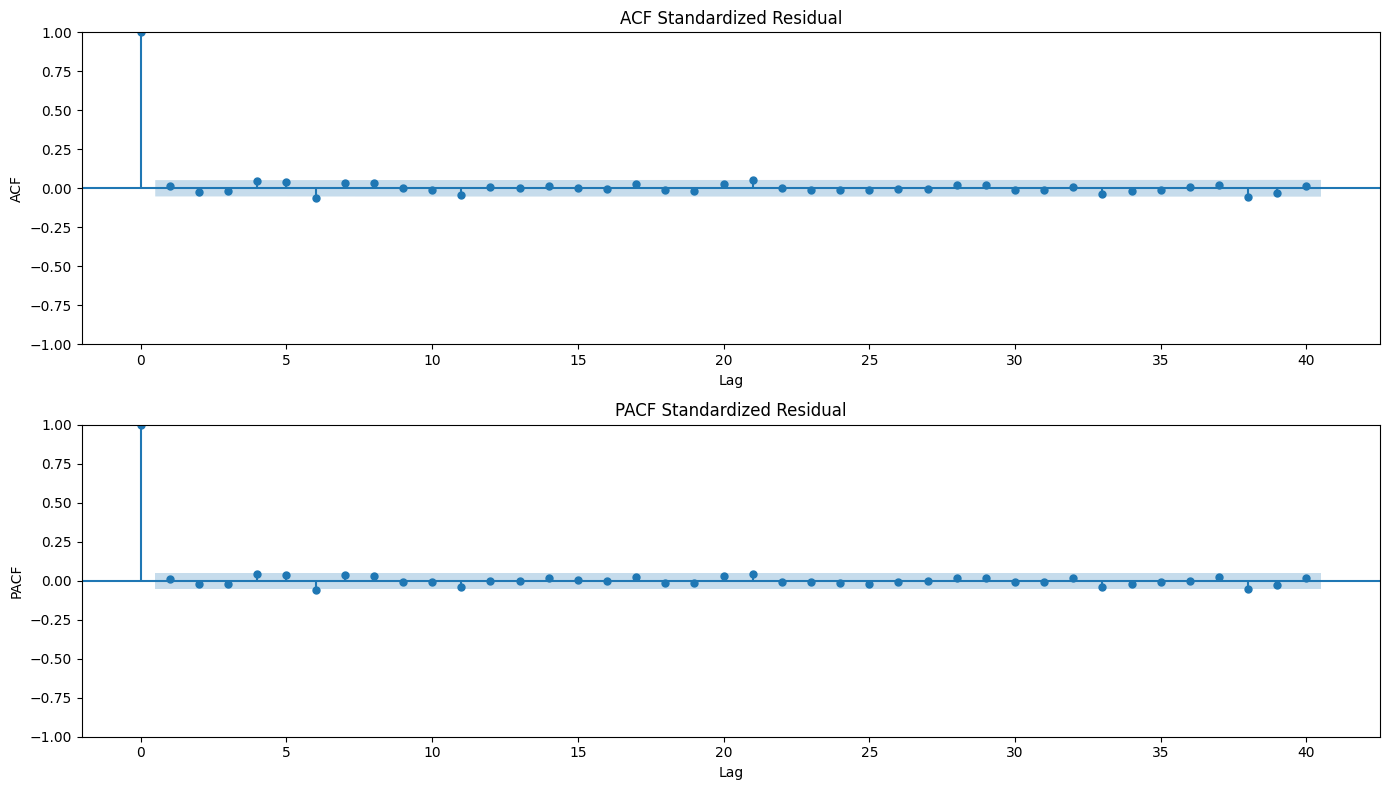

In [141]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF residual terstandarisasi
plot_acf(
    std_resid,
    lags=40,
    ax=axes[0]
)

axes[0].set_title("ACF Standardized Residual")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("ACF")

# PACF residual terstandarisasi
plot_pacf(
    std_resid,
    lags=40,
    ax=axes[1],
    method="ywm"
)

axes[1].set_title("PACF Standardized Residual")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("PACF")

plt.tight_layout()
plt.show()

<Figure size 1400x500 with 0 Axes>

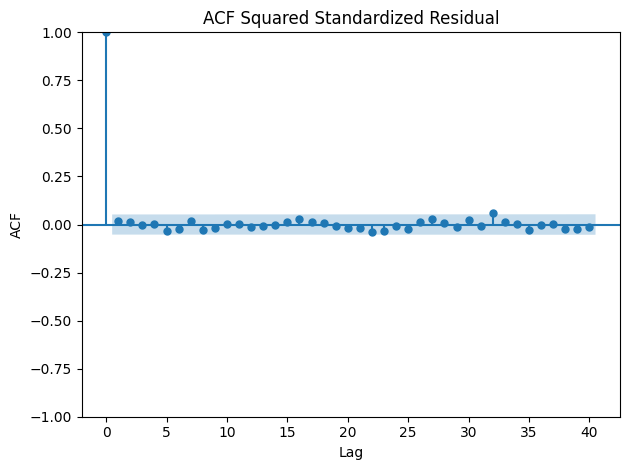

In [142]:
plt.figure(figsize=(14, 5))

plot_acf(
    std_resid**2,
    lags=40
)

plt.title("ACF Squared Standardized Residual")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.tight_layout()
plt.show()

In [143]:
print(hasil_garch.summary())

                           AR - GARCH Model Results                           
Dep. Variable:                   None   R-squared:                       0.002
Mean Model:                        AR   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:               -10492.6
Distribution:                  Normal   AIC:                           20995.3
Method:            Maximum Likelihood   BIC:                           21021.5
                                        No. Observations:                 1398
Date:                Fri, Oct 02 2026   Df Residuals:                     1396
Time:                        07:29:09   Df Model:                            2
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const       2131.4845     66.064     32.264 2.256e-228 [2.

In [144]:
# Parameter GARCH
alpha = hasil_garch.params["alpha[1]"]
beta = hasil_garch.params["beta[1]"]

print("======================================")
print("PARAMETER GARCH(1,1)")
print("======================================")
print(f"Alpha (α1) : {alpha:.4f}")
print(f"Beta  (β1) : {beta:.4f}")
print(f"α1 + β1    : {alpha + beta:.4f}")

PARAMETER GARCH(1,1)
Alpha (α1) : 0.0436
Beta  (β1) : 0.9379
α1 + β1    : 0.9815


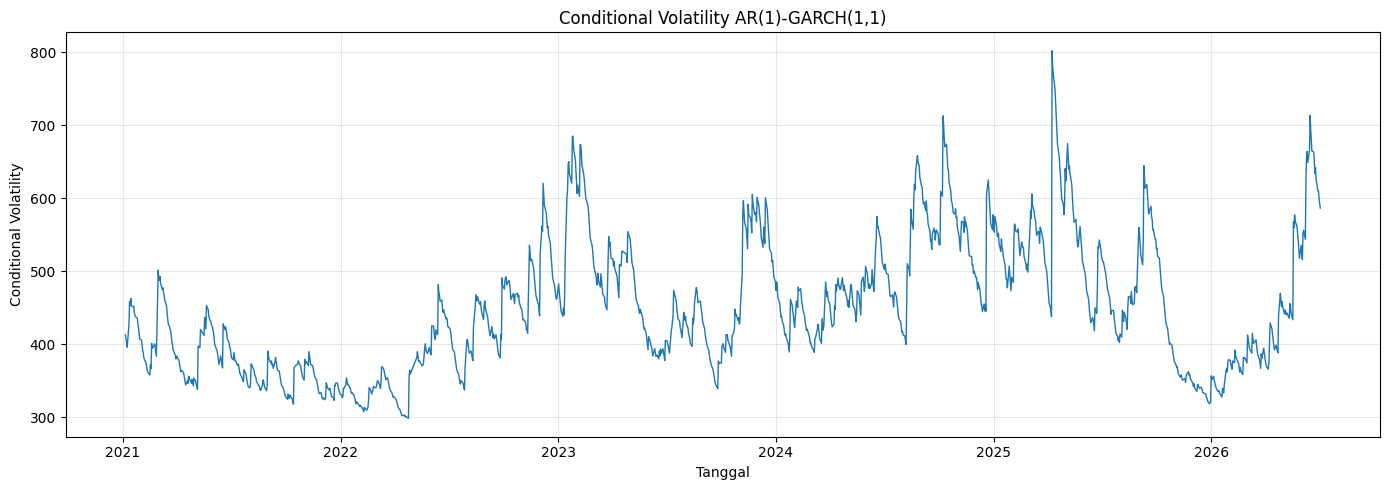

In [145]:
# Plot Conditional Volatility
plt.figure(figsize=(14, 5))

plt.plot(
    hasil_garch.conditional_volatility,
    linewidth=1
)

plt.title("Conditional Volatility AR(1)-GARCH(1,1)")
plt.xlabel("Tanggal")
plt.ylabel("Conditional Volatility")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

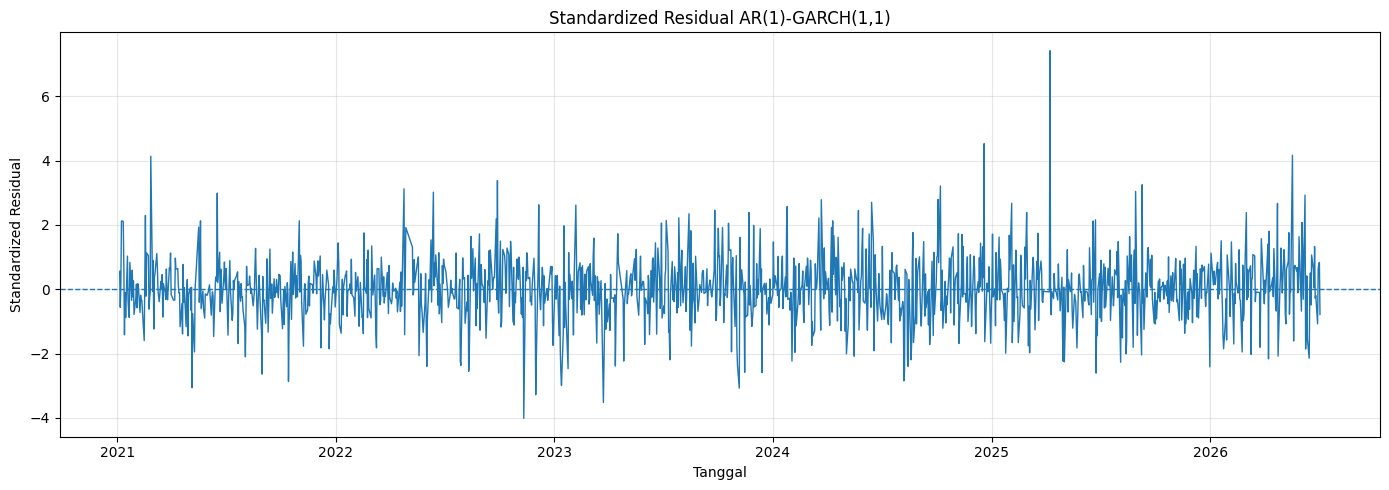

In [146]:
# Plot Standardized Residual
plt.figure(figsize=(14, 5))

plt.plot(
    std_resid,
    linewidth=1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Standardized Residual AR(1)-GARCH(1,1)")
plt.xlabel("Tanggal")
plt.ylabel("Standardized Residual")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [147]:
dist='normal'

In [148]:
from scipy.stats import jarque_bera

jb_test = jarque_bera(std_resid)

print("======================================")
print("UJI NORMALITAS JARQUE-BERA")
print("======================================")
print(f"JB Statistic : {jb_test.statistic:.4f}")
print(f"p-value      : {jb_test.pvalue:.4f}")

UJI NORMALITAS JARQUE-BERA
JB Statistic : 751.6021
p-value      : 0.0000


## Signifikansi Parameter

In [149]:
print("======================================")
print("PARAMETER MODEL AR(1)-GARCH(1,1)")
print("======================================")
print(hasil_garch.params)

print("\n======================================")
print("P-VALUE PARAMETER")
print("======================================")
print(hasil_garch.pvalues)

PARAMETER MODEL AR(1)-GARCH(1,1)
Const       2131.484540
None[1]        0.056402
omega       4154.654101
alpha[1]       0.043645
beta[1]        0.937867
Name: params, dtype: float64

P-VALUE PARAMETER
Const       2.256111e-228
None[1]      4.756054e-02
omega        8.681566e-01
alpha[1]     5.832571e-01
beta[1]      1.386650e-06
Name: pvalues, dtype: float64


In [166]:
omega = hasil_garch.params["omega"]
alpha = hasil_garch.params["alpha[1]"]
beta = hasil_garch.params["beta[1]"]

print("======================================")
print("PEMERIKSAAN PARAMETER GARCH(1,1)")
print("======================================")
print(f"Omega (ω)  : {omega:.6f}")
print(f"Alpha (α₁) : {alpha:.6f}")
print(f"Beta (β₁)  : {beta:.6f}")
print(f"α₁ + β₁    : {alpha + beta:.6f}")

PEMERIKSAAN PARAMETER GARCH(1,1)
Omega (ω)  : 4154.654101
Alpha (α₁) : 0.043645
Beta (β₁)  : 0.937867
α₁ + β₁    : 0.981512


## Forecasting Data Testing

In [167]:
y_all = pd.concat([y_train, y_test])

In [168]:
# ======================================
# ROLLING ONE-STEP-AHEAD FORECAST
# ======================================

forecast_diff = []
forecast_level = []

# Gabungkan data aktual
y_all = pd.concat([y_train, y_test])

# Differencing seluruh data
y_all_diff = y_all.diff().dropna()

# Shift untuk Box-Cox
y_all_shift = y_all_diff + shift

# Transformasi Box-Cox
y_all_boxcox = boxcox(
    y_all_shift,
    lmbda=lambda_fit
)

y_all_boxcox = pd.Series(
    y_all_boxcox,
    index=y_all_diff.index
)

# Rolling forecast
for i in range(len(y_test)):

    # Data yang tersedia sampai sebelum observasi
    # yang akan diramalkan
    end_idx = len(y_train_boxcox) + i

    data_roll = y_all_boxcox.iloc[:end_idx]

    # Model AR(1)-GARCH(1,1)
    model_roll = arch_model(
        data_roll,
        mean='ARX',
        lags=1,
        vol='GARCH',
        p=1,
        q=1,
        dist='normal'
    )

    hasil_roll = model_roll.fit(disp='off')

    # Forecast 1 langkah ke depan
    forecast_roll = hasil_roll.forecast(
        horizon=1,
        reindex=False
    )

    forecast_boxcox = forecast_roll.mean.iloc[-1, 0]

    # Kembalikan Box-Cox
    if lambda_fit != 0:
        forecast_shift = (
            lambda_fit * forecast_boxcox + 1
        ) ** (1 / lambda_fit)
    else:
        forecast_shift = np.exp(forecast_boxcox)

    # Hilangkan shift
    forecast_d = forecast_shift - shift

    forecast_diff.append(forecast_d)

    # ==================================
    # INVERSE DIFFERENCING
    # GUNAKAN NILAI AKTUAL SEBELUMNYA
    # ==================================

    if i == 0:
        previous_actual = y_train.iloc[-1]
    else:
        previous_actual = y_test.iloc[i - 1]

    forecast_y = previous_actual + forecast_d

    forecast_level.append(forecast_y)


forecast_level = pd.Series(
    forecast_level,
    index=y_test.index
)

/usr/local/lib/python3.13/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.082e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.13/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.081e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.13/dist-packages/arch/univariate/base

In [169]:
# Tabel Hasil Forecasting
tabel_forecast = pd.DataFrame({
    "Tanggal": y_test.index,
    "Aktual": y_test.values,
    "Forecast": forecast_level.values
})

print("======================================")
print("TABEL HASIL FORECASTING")
print("======================================")

display(tabel_forecast.head(20))

TABEL HASIL FORECASTING


,Tanggal,Aktual,Forecast
0,2026-07-06,17990.0,17951.572231
1,2026-07-07,17975.0,17996.015926
2,2026-07-08,17994.0,17978.115743
3,2026-07-09,18075.0,17998.841439
4,2026-07-10,18050.0,18083.672982
5,2026-07-13,18105.0,18052.620981
6,2026-07-14,18085.0,18112.087989
7,2026-07-15,18065.0,18087.921328
8,2026-07-16,17985.0,18067.910993
9,2026-07-17,17890.0,17984.792953


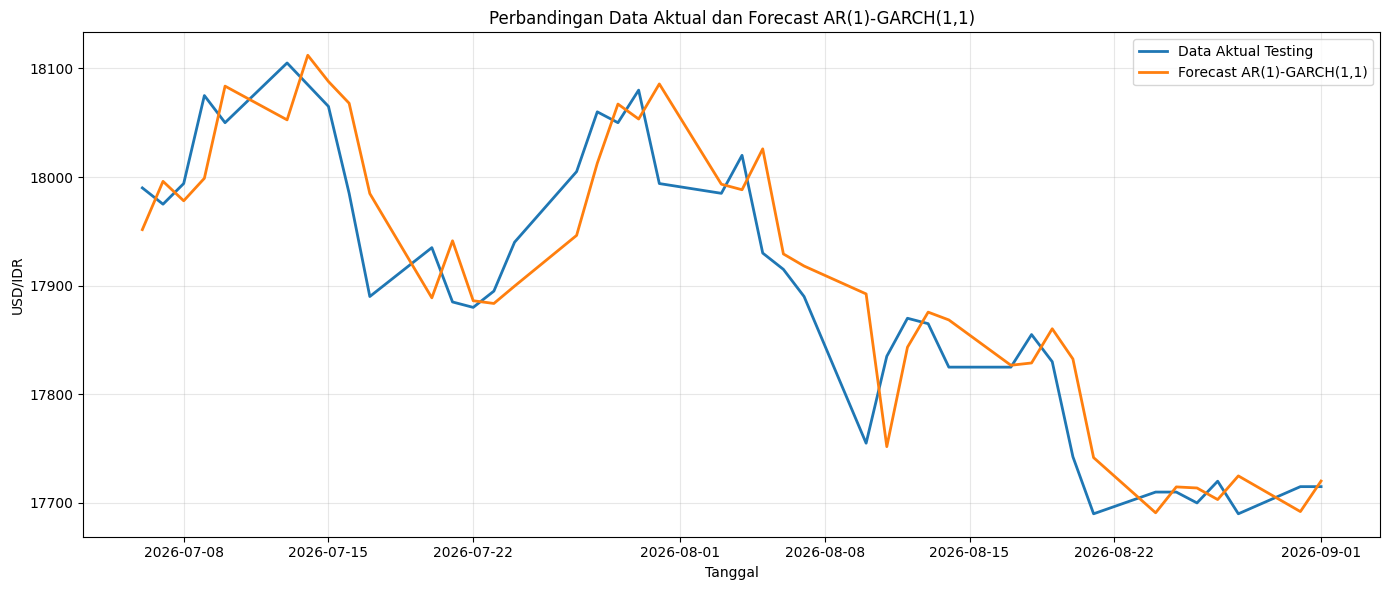

In [170]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test,
    label="Data Aktual Testing",
    linewidth=2
)

plt.plot(
    forecast_level.index,
    forecast_level,
    label="Forecast AR(1)-GARCH(1,1)",
    linewidth=2
)

plt.title("Perbandingan Data Aktual dan Forecast AR(1)-GARCH(1,1)")
plt.xlabel("Tanggal")
plt.ylabel("USD/IDR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [171]:
# ======================================
# TABEL HASIL FORECASTING DATA TESTING
# ======================================

tabel_forecast = pd.DataFrame({
    "Tanggal": y_test.index,
    "Aktual": y_test.values,
    "Forecast": forecast_level.values
})

# Error
tabel_forecast["Error"] = (
    tabel_forecast["Aktual"] -
    tabel_forecast["Forecast"]
)

# Absolute Error
tabel_forecast["Absolute Error"] = (
    tabel_forecast["Error"].abs()
)

# Absolute Percentage Error
tabel_forecast["APE (%)"] = (
    np.abs(
        (tabel_forecast["Aktual"] -
         tabel_forecast["Forecast"])
        / tabel_forecast["Aktual"]
    ) * 100
)

print("======================================")
print("TABEL HASIL FORECASTING")
print("======================================")

display(tabel_forecast.head(20))

TABEL HASIL FORECASTING


,Tanggal,Aktual,Forecast,Error,Absolute Error,APE (%)
0,2026-07-06,17990.0,17951.572231,38.427769,38.427769,0.213606
1,2026-07-07,17975.0,17996.015926,-21.015926,21.015926,0.116918
2,2026-07-08,17994.0,17978.115743,15.884257,15.884257,0.088275
3,2026-07-09,18075.0,17998.841439,76.158561,76.158561,0.421347
4,2026-07-10,18050.0,18083.672982,-33.672982,33.672982,0.186554
5,2026-07-13,18105.0,18052.620981,52.379019,52.379019,0.289307
6,2026-07-14,18085.0,18112.087989,-27.087989,27.087989,0.149782
7,2026-07-15,18065.0,18087.921328,-22.921328,22.921328,0.126883
8,2026-07-16,17985.0,18067.910993,-82.910993,82.910993,0.461001
9,2026-07-17,17890.0,17984.792953,-94.792953,94.792953,0.529866


## Evaluasi Akurasi Forecast

In [172]:
# ======================================
# EVALUASI AKURASI FORECAST
# ======================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# MSE
mse = mean_squared_error(
    y_test,
    forecast_level
)

# RMSE
rmse = np.sqrt(mse)

# MAE
mae = mean_absolute_error(
    y_test,
    forecast_level
)

# MAPE
mape = np.mean(
    np.abs(
        (y_test - forecast_level) /
        y_test
    )
) * 100

print("======================================")
print("EVALUASI FORECAST AR(1)-GARCH(1,1)")
print("======================================")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.4f}%")

EVALUASI FORECAST AR(1)-GARCH(1,1)
MSE  : 2522.9383
RMSE : 50.2289
MAE  : 39.6245
MAPE : 0.2213%


In [173]:
# ======================================
# TABEL RINGKASAN EVALUASI
# ======================================

evaluasi = pd.DataFrame({
    "Metrik": ["MSE", "RMSE", "MAE", "MAPE"],
    "Nilai": [mse, rmse, mae, mape]
})

print("======================================")
print("RINGKASAN HASIL EVALUASI")
print("======================================")

display(evaluasi)

RINGKASAN HASIL EVALUASI


,Metrik,Nilai
0,MSE,2522.938312
1,RMSE,50.228859
2,MAE,39.624466
3,MAPE,0.221312


## Forecast Data Historis

In [174]:
# ======================================
# DATA HISTORIS
# ======================================

y_historis = data["Terakhir"].copy()

print("Jumlah data historis :", len(y_historis))
print("Periode historis     :", y_historis.index.min(),
      "sampai", y_historis.index.max())

Jumlah data historis : 1442
Periode historis     : 2021-01-01 00:00:00 sampai 2026-09-01 00:00:00


In [175]:
# ======================================
# DIFFERENCING DATA HISTORIS
# ======================================

y_historis_diff = y_historis.diff().dropna()

In [176]:
# ======================================
# SHIFT
# ======================================

y_historis_shift = y_historis_diff + shift

In [177]:
# ======================================
# BOX-COX TRANSFORMATION
# ======================================

y_historis_boxcox = boxcox(
    y_historis_shift,
    lmbda=lambda_fit
)

y_historis_boxcox = pd.Series(
    y_historis_boxcox,
    index=y_historis_diff.index
)

In [178]:
lambda_fit

np.float64(1.3851558041847958)

In [179]:
# ======================================
# AR(1)-GARCH(1,1) DATA HISTORIS
# ======================================

model_historis = arch_model(
    y_historis_boxcox,
    mean='ARX',
    lags=1,
    vol='GARCH',
    p=1,
    q=1,
    dist='normal'
)

hasil_historis = model_historis.fit(
    disp='off'
)

print(hasil_historis.summary())

                           AR - GARCH Model Results                           
Dep. Variable:                   None   R-squared:                       0.002
Mean Model:                        AR   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:               -10810.1
Distribution:                  Normal   AIC:                           21630.3
Method:            Maximum Likelihood   BIC:                           21656.7
                                        No. Observations:                 1440
Date:                Fri, Oct 02 2026   Df Residuals:                     1438
Time:                        08:07:38   Df Model:                            2
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const       2132.1555     65.003     32.801 5.761e-236 [2.

/usr/local/lib/python3.13/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.082e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [180]:
# ======================================
# JUMLAH PERIODE FORECAST
# ======================================

horizon = 30

In [181]:
# ======================================
# FORECAST DATA HISTORIS
# ======================================

forecast_historis = hasil_historis.forecast(
    horizon=horizon,
    reindex=False
)

forecast_boxcox_historis = (
    forecast_historis.mean.iloc[-1].values
)

In [182]:
# ======================================
# INVERSE BOX-COX
# ======================================

if lambda_fit != 0:

    forecast_shift_historis = (
        lambda_fit * forecast_boxcox_historis + 1
    ) ** (1 / lambda_fit)

else:

    forecast_shift_historis = np.exp(
        forecast_boxcox_historis
    )

In [183]:
# ======================================
# MENGEMBALIKAN SHIFT
# ======================================

forecast_diff_historis = (
    forecast_shift_historis - shift
)

In [184]:
last_actual = y_historis.iloc[-1]

In [185]:
# ======================================
# INVERSE DIFFERENCING
# ======================================

forecast_level_historis = []

last_value = last_actual

for forecast_d in forecast_diff_historis:

    next_value = last_value + forecast_d

    forecast_level_historis.append(
        next_value
    )

    last_value = next_value

In [186]:
from pandas.tseries.offsets import BDay

tanggal_forecast = pd.date_range(
    start=y_historis.index[-1] + BDay(1),
    periods=horizon,
    freq="B"
)

In [187]:
# ======================================
# TABEL FORECAST DATA HISTORIS
# ======================================

tabel_forecast_historis = pd.DataFrame({
    "Tanggal": tanggal_forecast,
    "Forecast": forecast_level_historis
})

print("======================================")
print("FORECAST DATA HISTORIS")
print("======================================")

display(tabel_forecast_historis)

FORECAST DATA HISTORIS


,Tanggal,Forecast
0,2026-09-02,17718.743970
1,2026-09-03,17722.694603
2,2026-09-04,17726.656670
3,2026-09-07,17730.619368
4,2026-09-08,17734.582102
5,2026-09-09,17738.544838
6,2026-09-10,17742.507574
7,2026-09-11,17746.470309
8,2026-09-14,17750.433045
9,2026-09-15,17754.395781


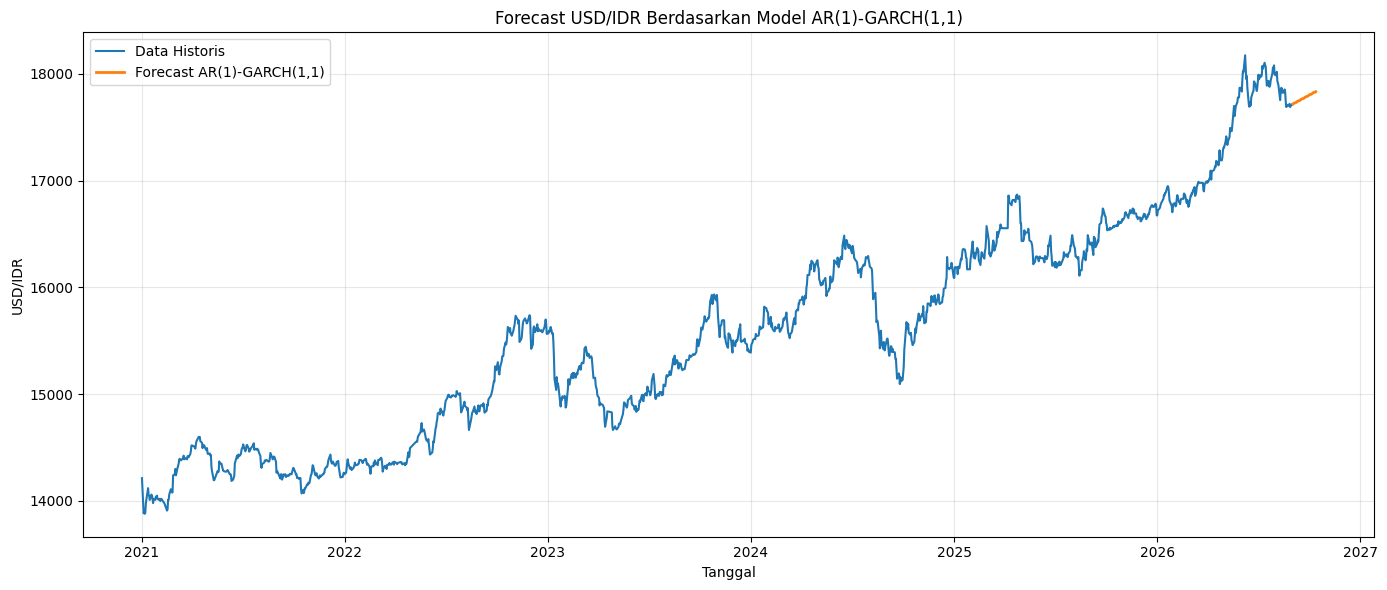

In [188]:
# ======================================
# PLOT HISTORIS + FORECAST
# ======================================

plt.figure(figsize=(14, 6))

plt.plot(
    y_historis.index,
    y_historis,
    label="Data Historis",
    linewidth=1.5
)

plt.plot(
    tanggal_forecast,
    forecast_level_historis,
    label="Forecast AR(1)-GARCH(1,1)",
    linewidth=2
)

plt.title(
    "Forecast USD/IDR Berdasarkan Model AR(1)-GARCH(1,1)"
)

plt.xlabel("Tanggal")
plt.ylabel("USD/IDR")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [189]:
# ======================================
# ROLLING ONE-STEP-AHEAD FORECAST
# DATA HISTORIS
# ======================================

forecast_diff_historis = []
forecast_level_historis = []

# Data historis
y_historis = data["Terakhir"].copy()

# ======================================
# DIFFERENCING
# ======================================

y_historis_diff = y_historis.diff().dropna()

# ======================================
# SHIFT UNTUK BOX-COX
# ======================================

y_historis_shift = y_historis_diff + shift

# ======================================
# TRANSFORMASI BOX-COX
# ======================================

y_historis_boxcox = boxcox(
    y_historis_shift,
    lmbda=lambda_fit
)

y_historis_boxcox = pd.Series(
    y_historis_boxcox,
    index=y_historis_diff.index
)

# ======================================
# ROLLING FORECAST
# ======================================

# Mulai dari jumlah data training
# supaya konsisten dengan evaluasi testing
start = len(y_train_boxcox)

for i in range(len(y_historis_boxcox) - start):

    # ==================================
    # DATA YANG TERSEDIA
    # ==================================

    end_idx = start + i

    data_roll = y_historis_boxcox.iloc[:end_idx]

    # ==================================
    # MODEL AR(1)-GARCH(1,1)
    # ==================================

    model_roll = arch_model(
        data_roll,
        mean='ARX',
        lags=1,
        vol='GARCH',
        p=1,
        q=1,
        dist='normal'
    )

    hasil_roll = model_roll.fit(disp='off')

    # ==================================
    # FORECAST 1 LANGKAH
    # ==================================

    forecast_roll = hasil_roll.forecast(
        horizon=1,
        reindex=False
    )

    forecast_boxcox = forecast_roll.mean.iloc[-1, 0]

    # ==================================
    # INVERSE BOX-COX
    # ==================================

    if lambda_fit != 0:

        forecast_shift = (
            lambda_fit * forecast_boxcox + 1
        ) ** (1 / lambda_fit)

    else:

        forecast_shift = np.exp(
            forecast_boxcox
        )

    # ==================================
    # KEMBALIKAN SHIFT
    # ==================================

    forecast_d = forecast_shift - shift

    forecast_diff_historis.append(
        forecast_d
    )

    # ==================================
    # INVERSE DIFFERENCING
    # GUNAKAN AKTUAL SEBELUMNYA
    # ==================================

    current_idx = start + i

    if current_idx == 0:

        previous_actual = y_historis.iloc[
            current_idx
        ]

    else:

        previous_actual = y_historis.iloc[
            current_idx
        ]

    forecast_y = previous_actual + forecast_d

    forecast_level_historis.append(
        forecast_y
    )

/usr/local/lib/python3.13/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.082e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.13/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.081e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.13/dist-packages/arch/univariate/base

In [190]:
# ======================================
# ROLLING ONE-STEP-AHEAD FORECAST
# SELURUH PERIODE HISTORIS SETELAH TRAIN
# ======================================

forecast_level_historis = []

start = len(y_train)

for i in range(start, len(y_historis)):

    # ----------------------------------
    # DATA YANG TERSEDIA SEBELUM
    # OBSERVASI KE-i
    # ----------------------------------

    data_roll = y_historis_boxcox.iloc[:i-1]

    # ----------------------------------
    # FIT AR(1)-GARCH(1,1)
    # ----------------------------------

    model_roll = arch_model(
        data_roll,
        mean='ARX',
        lags=1,
        vol='GARCH',
        p=1,
        q=1,
        dist='normal'
    )

    hasil_roll = model_roll.fit(disp='off')

    # ----------------------------------
    # FORECAST 1 LANGKAH
    # ----------------------------------

    forecast_roll = hasil_roll.forecast(
        horizon=1,
        reindex=False
    )

    forecast_boxcox = forecast_roll.mean.iloc[-1, 0]

    # ----------------------------------
    # INVERSE BOX-COX
    # ----------------------------------

    if lambda_fit != 0:

        forecast_shift = (
            lambda_fit * forecast_boxcox + 1
        ) ** (1 / lambda_fit)

    else:

        forecast_shift = np.exp(
            forecast_boxcox
        )

    # ----------------------------------
    # HILANGKAN SHIFT
    # ----------------------------------

    forecast_d = forecast_shift - shift

    # ----------------------------------
    # INVERSE DIFFERENCING
    # ----------------------------------

    previous_actual = y_historis.iloc[i-1]

    forecast_y = previous_actual + forecast_d

    forecast_level_historis.append(
        forecast_y
    )

/usr/local/lib/python3.13/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.082e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.13/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.081e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.13/dist-packages/arch/univariate/base

In [191]:
forecast_level_historis = pd.Series(
    forecast_level_historis,
    index=y_historis.index[start:]
)

In [192]:
# ======================================
# TABEL FORECAST DATA HISTORIS
# ======================================

tabel_forecast_historis = pd.DataFrame({
    "Tanggal": y_historis.index[start:],
    "Aktual": y_historis.iloc[start:].values,
    "Forecast": forecast_level_historis.values
})

# Error
tabel_forecast_historis["Error"] = (
    tabel_forecast_historis["Aktual"]
    - tabel_forecast_historis["Forecast"]
)

# Absolute Error
tabel_forecast_historis["Absolute Error"] = (
    tabel_forecast_historis["Error"].abs()
)

# APE
tabel_forecast_historis["APE (%)"] = (
    np.abs(
        tabel_forecast_historis["Error"]
        / tabel_forecast_historis["Aktual"]
    ) * 100
)

display(tabel_forecast_historis.head(20))

,Tanggal,Aktual,Forecast,Error,Absolute Error,APE (%)
0,2026-07-06,17990.0,17951.572231,38.427769,38.427769,0.213606
1,2026-07-07,17975.0,17996.015926,-21.015926,21.015926,0.116918
2,2026-07-08,17994.0,17978.115743,15.884257,15.884257,0.088275
3,2026-07-09,18075.0,17998.841439,76.158561,76.158561,0.421347
4,2026-07-10,18050.0,18083.672982,-33.672982,33.672982,0.186554
5,2026-07-13,18105.0,18052.620981,52.379019,52.379019,0.289307
6,2026-07-14,18085.0,18112.087989,-27.087989,27.087989,0.149782
7,2026-07-15,18065.0,18087.921328,-22.921328,22.921328,0.126883
8,2026-07-16,17985.0,18067.910993,-82.910993,82.910993,0.461001
9,2026-07-17,17890.0,17984.792953,-94.792953,94.792953,0.529866


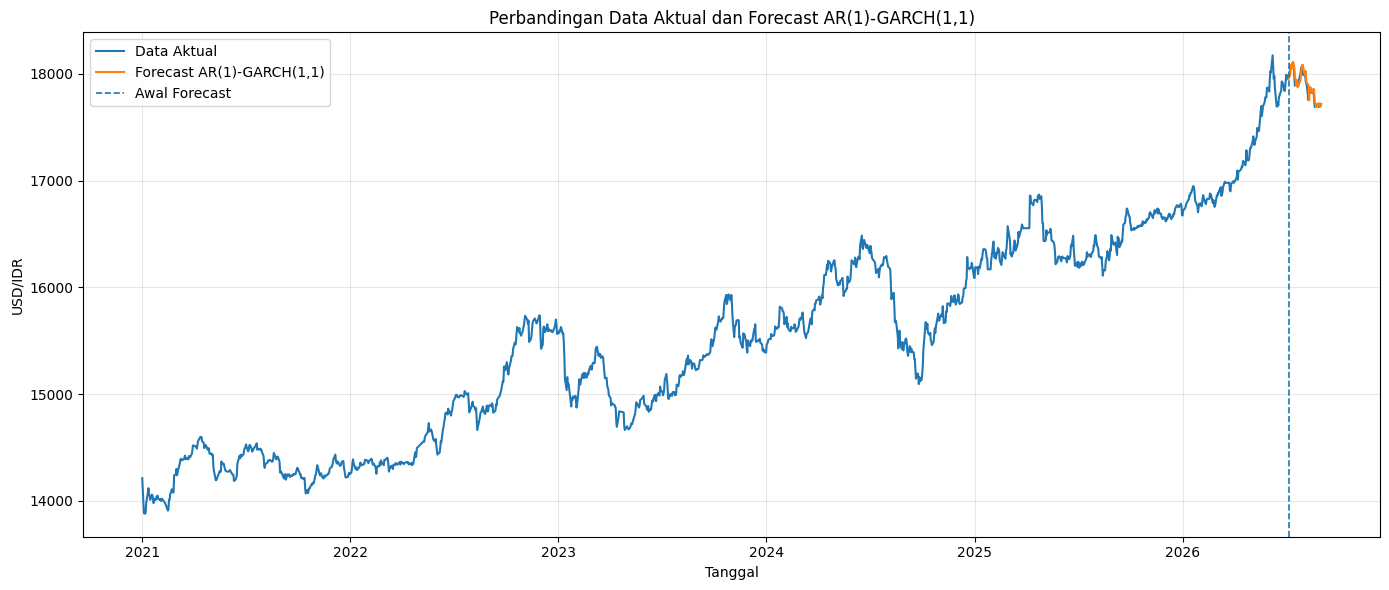

In [193]:
# ======================================
# PLOT AKTUAL VS FORECAST
# ======================================

plt.figure(figsize=(14, 6))

plt.plot(
    y_historis.index,
    y_historis,
    label="Data Aktual",
    linewidth=1.5
)

plt.plot(
    tabel_forecast_historis["Tanggal"],
    tabel_forecast_historis["Forecast"],
    label="Forecast AR(1)-GARCH(1,1)",
    linewidth=1.5
)

# Garis pemisah awal forecast
plt.axvline(
    y_historis.index[start],
    linestyle="--",
    linewidth=1.2,
    label="Awal Forecast"
)

plt.title(
    "Perbandingan Data Aktual dan Forecast "
    "AR(1)-GARCH(1,1)"
)

plt.xlabel("Tanggal")
plt.ylabel("USD/IDR")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()